Loading required package: caret

Loading required package: ggplot2

Loading required package: lattice

Loading required package: Metrics


Attaching package: 'Metrics'


The following objects are masked from 'package:caret':

    precision, recall


Loading required package: brnn

Loading required package: Formula

Loading required package: truncnorm



Target: Jsc 
Number of parameters (weights and biases) to estimate: 9 
Nguyen-Widrow method
Scaling factor= 0.7 
gamma= 7.7314 	 alpha= 1.5997 	 beta= 3.5084 
Number of parameters (weights and biases) to estimate: 18 
Nguyen-Widrow method
Scaling factor= 0.7015085 
gamma= 15.5694 	 alpha= 0.45 	 beta= 4.5495 
Number of parameters (weights and biases) to estimate: 27 
Nguyen-Widrow method
Scaling factor= 0.7023924 
gamma= 23.864 	 alpha= 0.2821 	 beta= 5.9604 
Number of parameters (weights and biases) to estimate: 36 
Nguyen-Widrow method
Scaling factor= 0.7030202 
gamma= 29.8171 	 alpha= 0.3229 	 beta= 6.4977 
Number of parameters (weights and biases) to estimate: 45 
Nguyen-Widrow method
Scaling factor= 0.7035075 
gamma= 36.2542 	 alpha= 0.3767 	 beta= 6.9644 
Number of parameters (weights and biases) to estimate: 9 
Nguyen-Widrow method
Scaling factor= 0.7 
gamma= 7.7036 	 alpha= 1.7024 	 beta= 3.4904 
Number of parameters (weights and biases) to estimate: 18 
Nguyen-Widrow method
Sc

Target: FF 


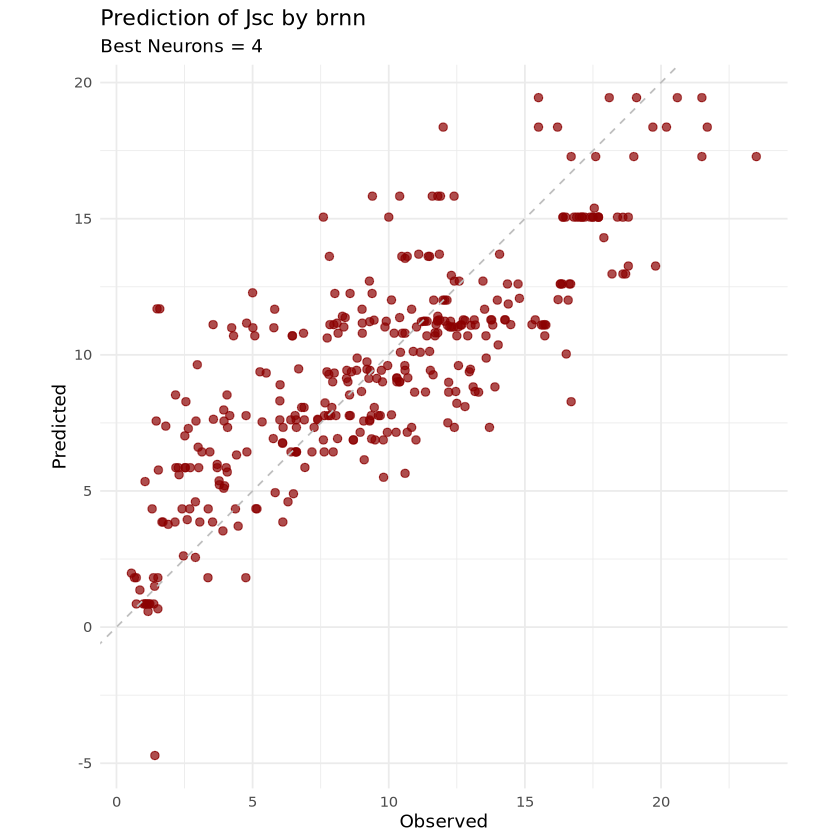

Number of parameters (weights and biases) to estimate: 9 
Nguyen-Widrow method
Scaling factor= 0.7 
gamma= 7.0736 	 alpha= 2.0462 	 beta= 4.5811 
Number of parameters (weights and biases) to estimate: 18 
Nguyen-Widrow method
Scaling factor= 0.7015038 
gamma= 13.8227 	 alpha= 0.7098 	 beta= 5.1376 
Number of parameters (weights and biases) to estimate: 27 
Nguyen-Widrow method
Scaling factor= 0.7023849 
gamma= 21.6055 	 alpha= 0.4618 	 beta= 6.4569 
Number of parameters (weights and biases) to estimate: 36 
Nguyen-Widrow method
Scaling factor= 0.7030108 
gamma= 29.2063 	 alpha= 0.5313 	 beta= 6.6953 
Number of parameters (weights and biases) to estimate: 45 
Nguyen-Widrow method
Scaling factor= 0.7034967 
gamma= 37.4937 	 alpha= 0.2792 	 beta= 7.9515 
Number of parameters (weights and biases) to estimate: 9 
Nguyen-Widrow method
Scaling factor= 0.7 
gamma= 7.2084 	 alpha= 1.8159 	 beta= 4.2977 
Number of parameters (weights and biases) to estimate: 18 
Nguyen-Widrow method
Scaling fact

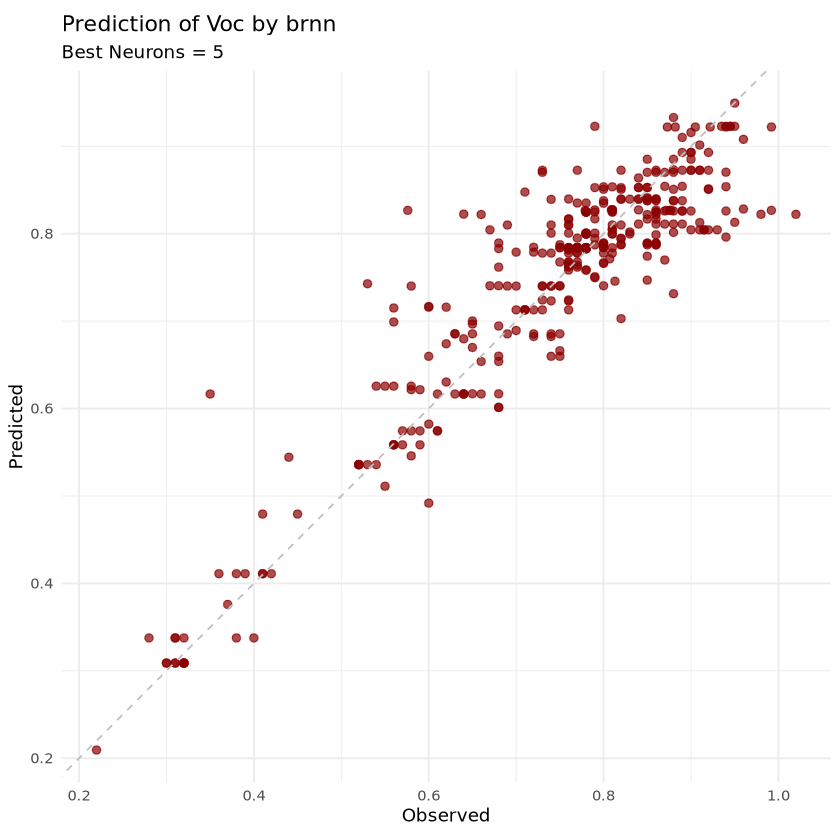

Number of parameters (weights and biases) to estimate: 9 
Nguyen-Widrow method
Scaling factor= 0.7 
gamma= 7.7548 	 alpha= 1.5551 	 beta= 2.6644 
Number of parameters (weights and biases) to estimate: 18 
Nguyen-Widrow method
Scaling factor= 0.7015038 
gamma= 15.2481 	 alpha= 0.4188 	 beta= 3.3098 
Number of parameters (weights and biases) to estimate: 27 
Nguyen-Widrow method
Scaling factor= 0.7023849 
gamma= 22.9865 	 alpha= 0.3093 	 beta= 4.0774 
Number of parameters (weights and biases) to estimate: 36 
Nguyen-Widrow method
Scaling factor= 0.7030108 
gamma= 27.3198 	 alpha= 0.4835 	 beta= 4.1329 
Number of parameters (weights and biases) to estimate: 45 
Nguyen-Widrow method
Scaling factor= 0.7034967 
gamma= 34.9243 	 alpha= 0.3573 	 beta= 4.4836 
Number of parameters (weights and biases) to estimate: 9 
Nguyen-Widrow method
Scaling factor= 0.7 
gamma= 7.8154 	 alpha= 1.3983 	 beta= 2.7901 
Number of parameters (weights and biases) to estimate: 18 
Nguyen-Widrow method
Scaling fact

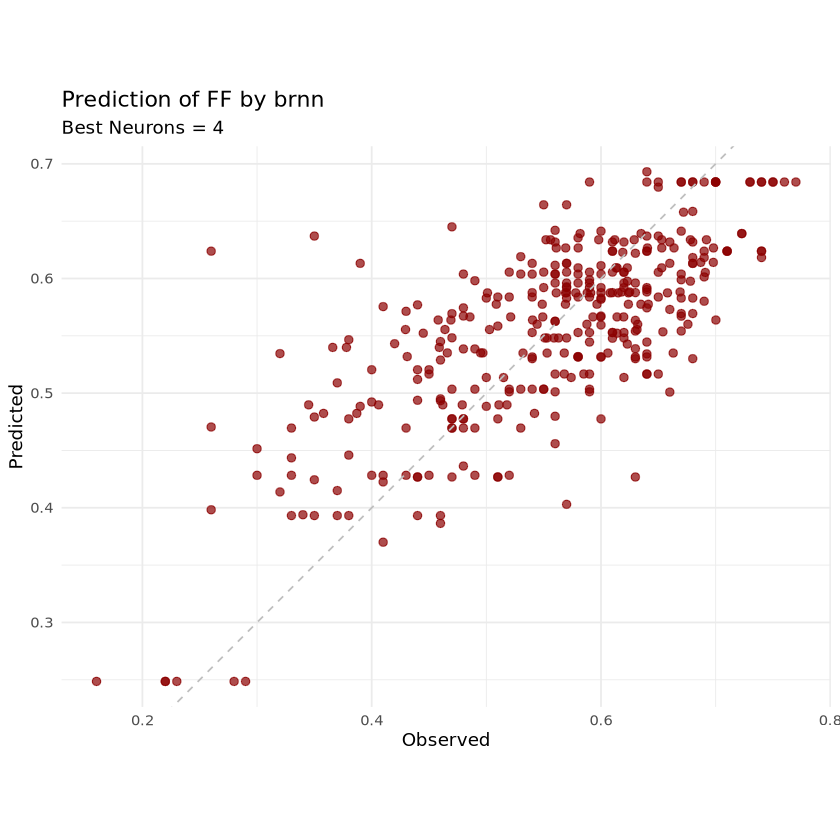

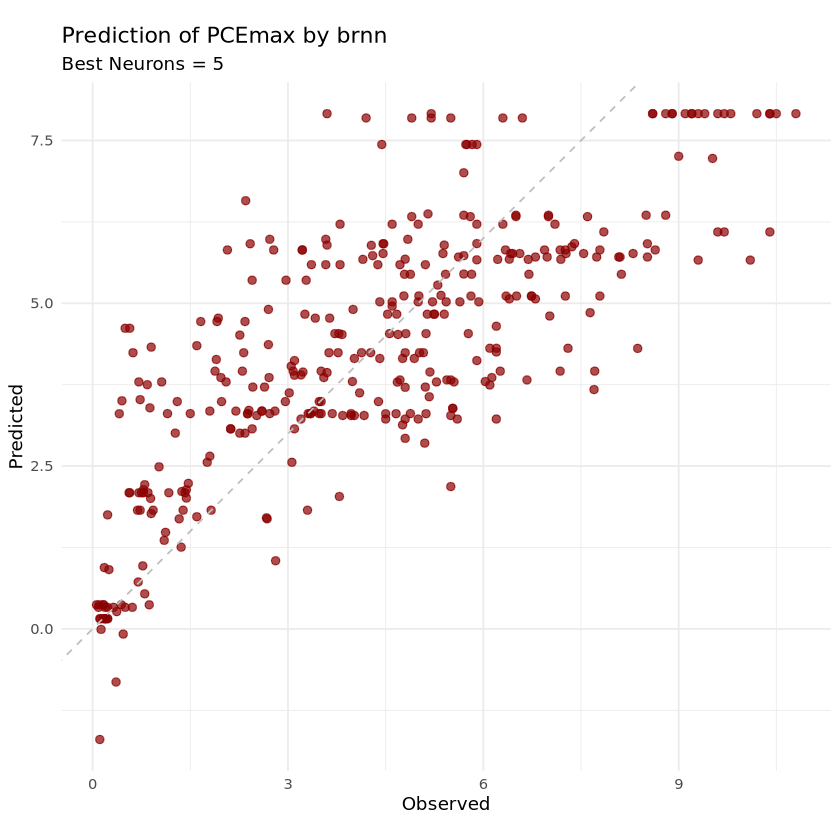

In [1]:
# --- ライブラリ読み込み ---
if (!require(caret)) install.packages("caret"); library(caret)
if (!require(Metrics)) install.packages("Metrics"); library(Metrics)
if (!require(ggplot2)) install.packages("ggplot2"); library(ggplot2)
if (!require(brnn)) install.packages("brnn"); library(brnn)

# --- データ読み込み ---
data_path <- "/Volumes/csbdeep11/_yasu-i/20250303_rebuiled/20220127_PLS 202201 ALL/n_base.csv"
data_all <- read.csv(data_path, row.names = 1)

# --- 目的変数名の設定 ---
target_vars <- c("Jsc", "Voc", "FF", "PCEmax")

# --- 結果保存用 ---
results_list <- list()
plots_list <- list()

for (target in target_vars) {
  cat("====================================\n")
  cat("Target:", target, "\n")
  cat("====================================\n")
  
  # --- 欠損処理とスケーリング ---
  data_clean <- data_all[complete.cases(data_all[, target]), ]
  y <- data_clean[[target]]
  X <- data_clean[, !(colnames(data_all) %in% target_vars)]
  X <- X[, sapply(X, function(x) sd(x) != 0)]
  X_scaled <- scale(X)
  data_model <- data.frame(y = y, X_scaled)

  # --- モデル学習（10-fold CV）---
  set.seed(42)
  model <- train(
    y ~ .,
    data = data_model,
    method = "brnn",
    trControl = trainControl(method = "cv", number = 10),
    tuneLength = 5
  )

  # --- 予測と指標の計算 ---
  pred <- predict(model, newdata = data_model)
  r2 <- cor(y, pred)^2
  rmse_val <- RMSE(pred, y)
  mae_val <- MAE(pred, y)
  sd_y <- sd(y)
  rpd_val <- sd_y / rmse_val
  press <- sum((y - pred)^2)
  tss <- sum((y - mean(y))^2)
  q2_val <- 1 - (press / tss)

  # --- パラメータ表示 ---
  cat("Best Parameters:\n")
  print(model$bestTune)
  cat(sprintf("R2         = %.4f\n", r2))
  cat(sprintf("corALL     = %.4f\n", sqrt(r2)))
  cat(sprintf("RMSE       = %.4f\n", rmse_val))
  cat(sprintf("MAE        = %.4f\n", mae_val))
  cat(sprintf("RPD        = %.4f\n", rpd_val))
  cat(sprintf("Q2         = %.4f\n", q2_val))

  # --- プロット ---
  df_plot <- data.frame(Observed = y, Predicted = pred)
  p <- ggplot(df_plot, aes(x = Observed, y = Predicted)) +
    geom_point(color = "darkred", alpha = 0.7, size = 2) +
    geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "gray") +
    coord_fixed() +
    theme_minimal() +
    labs(title = paste("Prediction of", target, "by brnn"),
         subtitle = paste("Best Neurons =", model$bestTune$neurons),
         x = "Observed", y = "Predicted")
  
  print(p)
  ggsave(filename = paste0("plot_brnn_", target, ".pdf"), plot = p, width = 6, height = 6)

  # --- 結果保存 ---
  results_list[[target]] <- list(model = model, R2 = r2, RMSE = rmse_val, MAE = mae_val, RPD = rpd_val, Q2 = q2_val)
  plots_list[[target]] <- p
}

# --- サマリー出力 ---
summary_df <- do.call(rbind, lapply(names(results_list), function(tgt) {
  cbind(Target = tgt, as.data.frame(results_list[[tgt]][-1]))
}))
write.csv(summary_df, "brnn_summary.csv", row.names = FALSE)
